# Question 3: Brownian motion and Ito calculus

We compute $I(T, \Delta t) = \sum_{i=0}^{N-1} (\Delta Z_i)^2$ with $\Delta Z_i = \phi(t_i)\sqrt{\Delta t}$, $\phi(t_i) \sim N(0,1)$ and $\Delta t = T/N$, over 70,000 paths for each $N$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Parameters & Given Info
T = 2
n_paths = 70000
N_values = [100, 200, 400, 800, 1600, 3200, 6400]

In [3]:
dt_values = []   # Storage of dt for each N
mean_values = [] # Storage of the mean of I(T, dt) for each N
var_values = []  # Storage of the variance of I(T, dt) for each N

for N in N_values:
    dt = T/N
    I = np.zeros(n_paths) # running sum of (dZ)^2 for every path
    for i in range(N):    # the only explicit loop: over the timesteps
        dZ = np.random.normal(0, 1, n_paths)*np.sqrt(dt) # one increment per path
        I = I + dZ**2
    dt_values.append(dt)
    mean_values.append(np.mean(I))
    var_values.append(np.var(I))

In [4]:
# Text table of the results, with the exact values E[I] = T and Var[I] = 2*T*dt for comparison
print(f"{'N':>6} {'dt':>10} {'mean I':>10} {'exact mean':>11} {'var I':>12} {'exact var':>12}")
for k in range(len(N_values)):
    print(f"{N_values[k]:>6} {dt_values[k]:>10.6f} {mean_values[k]:>10.6f} {T:>11.6f} "
          f"{var_values[k]:>12.6e} {2*T*dt_values[k]:>12.6e}")

     N         dt     mean I  exact mean        var I    exact var
   100   0.020000   1.999143    2.000000 7.996543e-02 8.000000e-02
   200   0.010000   1.999471    2.000000 4.016201e-02 4.000000e-02
   400   0.005000   2.000152    2.000000 2.000789e-02 2.000000e-02
   800   0.002500   1.999707    2.000000 1.004548e-02 1.000000e-02
  1600   0.001250   2.000058    2.000000 4.996978e-03 5.000000e-03
  3200   0.000625   2.000136    2.000000 2.505466e-03 2.500000e-03
  6400   0.000313   2.000111    2.000000 1.245386e-03 1.250000e-03


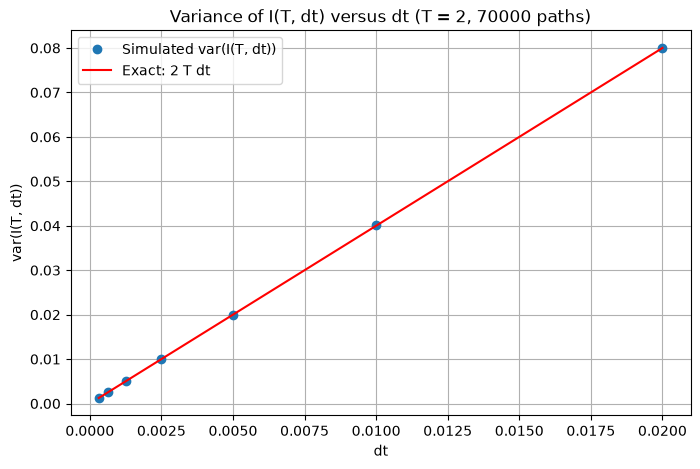

In [5]:
# Plot var(I(T, dt)) versus dt
dt_array = np.array(dt_values)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dt_array, var_values, 'o', label='Simulated var(I(T, dt))')
ax.plot(dt_array, 2*T*dt_array, color='red', label='Exact: 2 T dt')

ax.set_title(f'Variance of I(T, dt) versus dt (T = {T}, {n_paths} paths)')
ax.set_xlabel('dt')
ax.set_ylabel('var(I(T, dt))')
ax.legend()
ax.grid(True)
plt.show()

## Observations

**Mean.** For every $N$, the mean of $I(T,\Delta t)$ is very close to $T = 2$, whatever the value of $\Delta t$. This is because $\phi \sim N(0,1)$ has $E[\phi^2] = 1$, so

$$E[(\Delta Z_i)^2] = \Delta t\, E[\phi_i^2] = \Delta t, \qquad E[I] = \sum_{i=0}^{N-1} \Delta t = N\Delta t = T.$$

**Variance.** The variance falls in proportion to $\Delta t$: each time $N$ doubles, the variance halves, and the points lie on a straight line through the origin. For a standard normal, $E[\phi^4] = 3$, so

$$\mathrm{Var}[(\Delta Z_i)^2] = \Delta t^2\left(E[\phi_i^4] - E[\phi_i^2]^2\right) = \Delta t^2 (3 - 1) = 2\Delta t^2.$$

The increments $\Delta Z_i$ are independent, so the variances add:

$$\mathrm{Var}[I] = \sum_{i=0}^{N-1} 2\Delta t^2 = 2N\Delta t^2 = 2T\,\Delta t.$$

With $T = 2$ this is $4\Delta t$, which matches the simulated variances (red line) up to Monte Carlo noise.

**Conclusion.** As $\Delta t \to 0$, $E[I] = T$ while $\mathrm{Var}[I] = 2T\Delta t \to 0$. So

$$E\left[(I(T,\Delta t) - T)^2\right] = \mathrm{Var}[I] = 2T\Delta t \to 0,$$

which means $I(T, \Delta t)$ converges to $T$ in mean square. Even though each $\Delta Z_i$ is random, the sum of their squares becomes deterministic in the limit:

$$\int_0^T (dZ)^2 = \int_0^T dt = T.$$

This is the Ito calculus rule $(dZ)^2 = dt$: the squared Brownian increment can be replaced by $dt$ inside stochastic integrals. It is why Ito's lemma includes a second-derivative term $\tfrac12 \sigma^2 \frac{\partial^2 f}{\partial X^2}\,dt$ that ordinary calculus doesn't have.